In [303]:
import re
import warnings

import matplotlib.pyplot as plt
import nltk
import pandas as pd
import seaborn as sns
import spacy
from nltk.corpus import stopwords
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from unidecode import unidecode

import numpy as np

warnings.filterwarnings("ignore")


def ensure_stop_words_downloaded():
    try:
        nltk.data.find("corpora/stopwords")
    except LookupError:
        nltk.download("stopwords")


ensure_stop_words_downloaded()

In [304]:
critiques = [
    "Ce film est absolument fantastique! La cinématographie est magnifique.",
    "Quel ennui... le scénario est prévisible et les acteurs sans charisme.",
    "Un excellent film! Très émouvant et bien réalisé. À voir!",
    "Décevant. Les effets spéciaux sont bons mais l'histoire manque de profondeur.",
    "Masterpiece! Un incontournable. Brillant du début à la fin.",
    "Horrible film. Perte de temps totale. Pas recommandé.",
]

labels = [1, 0, 1, 0, 1, 0]  # 1 = positif, 0 = négatif

### Tâche 1 : Count Vectorizer (Bag of Words)

1. Utilisez `CountVectorizer` de scikit-learn sur le corpus
2. Configurez-le pour :
   - Convertir en minuscules
   - Supprimer les stopwords français
   - Ignorer les termes qui apparaissent dans moins de 1 document
   - Limiter à 100 termes maximum
3. Affichez :
   - La forme de la matrice (nombre de documents x nombre de features)
   - Les noms des features (vocabulaire)
   - La matrice de densité

**Attendus** : Matrice Bag of Words, visualisation du vocabulaire

In [305]:
count_vectorizer = CountVectorizer(
    lowercase=True,
    stop_words=stopwords.words("french"),
    min_df=1,
    max_features=100,
)

X_count_vectorizer = count_vectorizer.fit_transform(critiques)

In [306]:
print(
    f"Dimensions de X : {X_count_vectorizer.shape[0]} lignes et {X_count_vectorizer.shape[1]} colonnes"
)
print("\nFeatures :\n", count_vectorizer.get_feature_names_out())
print("\nMatrice de densité :\n", X_count_vectorizer.toarray())

Dimensions de X : 6 lignes et 35 colonnes

Features :
 ['absolument' 'acteurs' 'bien' 'bons' 'brillant' 'charisme'
 'cinématographie' 'début' 'décevant' 'effets' 'ennui' 'excellent'
 'fantastique' 'film' 'fin' 'histoire' 'horrible' 'incontournable'
 'magnifique' 'manque' 'masterpiece' 'perte' 'profondeur' 'prévisible'
 'quel' 'recommandé' 'réalisé' 'sans' 'scénario' 'spéciaux' 'temps'
 'totale' 'très' 'voir' 'émouvant']

Matrice de densité :
 [[1 0 0 0 0 0 1 0 0 0 0 0 1 1 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 1 0 0 0 1 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 1 1 0 0 0 0 0 0]
 [0 0 1 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 1 1]
 [0 0 0 1 0 0 0 0 1 1 0 0 0 0 0 1 0 0 0 1 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0]
 [0 0 0 0 1 0 0 1 0 0 0 0 0 0 1 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 1 0 0 0 1 0 0 0 0 1 1 0 0 0]]


### Tâche 2 : Analyse du vocabulaire

1. Calculez la fréquence de chaque term dans le corpus
2. Identifiez les 10 termes les plus fréquents
3. Affichez-les avec leurs comptes
4. Analysez : ces termes sont-ils pertinents pour la classification sentiments?

**Attendus** : Ranking des termes, analyse critique

In [307]:
word_frequency = X_count_vectorizer.sum(axis=0) / X_count_vectorizer.sum() * 100
word_frequency = np.asarray(word_frequency).flatten()
print("Fréquence de chaque mot :\n", word_frequency)

Fréquence de chaque mot :
 [2.7027027  2.7027027  2.7027027  2.7027027  2.7027027  2.7027027
 2.7027027  2.7027027  2.7027027  2.7027027  2.7027027  2.7027027
 2.7027027  8.10810811 2.7027027  2.7027027  2.7027027  2.7027027
 2.7027027  2.7027027  2.7027027  2.7027027  2.7027027  2.7027027
 2.7027027  2.7027027  2.7027027  2.7027027  2.7027027  2.7027027
 2.7027027  2.7027027  2.7027027  2.7027027  2.7027027 ]


In [308]:
word_frequency_df = pd.DataFrame(
    data={
        "word": count_vectorizer.get_feature_names_out(),
        "count": np.asarray(X_count_vectorizer.sum(axis=0)).flatten(),
        "frequency": word_frequency.flatten(),
    }
)

top10_frequency = word_frequency_df.nlargest(10, "frequency")
top10_frequency.head(10)

,word,count,frequency
13,film,3,8.108108
0,absolument,1,2.702703
1,acteurs,1,2.702703
2,bien,1,2.702703
3,bons,1,2.702703
4,brillant,1,2.702703
5,charisme,1,2.702703
6,cinématographie,1,2.702703
7,début,1,2.702703
8,décevant,1,2.702703


Il n'est peut-être pas pertinent de conserver le mot film puisque l'objet de l'étude est l'analyse des critiques de films.

### Tâche 3 : TF-IDF Vectorizer

1. Utilisez `TfidfVectorizer` sur le même corpus
2. Configurez-le avec les mêmes paramètres que CountVectorizer
3. Comparez :
   - La matrice TF-IDF avec la matrice Bag of Words
   - Les scores TF-IDF des 5 premiers documents
4. Démontrez pourquoi TF-IDF est supérieur à BoW pour identifier les termes discriminants

**Attendus** : Matrice TF-IDF, comparaison quantifiée BoW vs TF-IDF

In [309]:
tfidf_vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words=stopwords.words("french"),
    min_df=1,
    max_features=100,
)

X_tfidf_vectorizer = tfidf_vectorizer.fit_transform(critiques)

In [310]:
print(
    f"Dimensions de X : {X_tfidf_vectorizer.shape[0]} lignes et {X_tfidf_vectorizer.shape[1]} colonnes"
)
print("\nFeatures :\n", tfidf_vectorizer.get_feature_names_out())
print("\nMatrice de densité :\n", X_tfidf_vectorizer.toarray().round(3))

Dimensions de X : 6 lignes et 35 colonnes

Features :
 ['absolument' 'acteurs' 'bien' 'bons' 'brillant' 'charisme'
 'cinématographie' 'début' 'décevant' 'effets' 'ennui' 'excellent'
 'fantastique' 'film' 'fin' 'histoire' 'horrible' 'incontournable'
 'magnifique' 'manque' 'masterpiece' 'perte' 'profondeur' 'prévisible'
 'quel' 'recommandé' 'réalisé' 'sans' 'scénario' 'spéciaux' 'temps'
 'totale' 'très' 'voir' 'émouvant']

Matrice de densité :
 [[0.472 0.    0.    0.    0.    0.    0.472 0.    0.    0.    0.    0.
  0.472 0.327 0.    0.    0.    0.    0.472 0.    0.    0.    0.    0.
  0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.   ]
 [0.    0.378 0.    0.    0.    0.378 0.    0.    0.    0.    0.378 0.
  0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.378
  0.378 0.    0.    0.378 0.378 0.    0.    0.    0.    0.    0.   ]
 [0.    0.    0.393 0.    0.    0.    0.    0.    0.    0.    0.    0.393
  0.    0.272 0.    0.    0.    0.    0.    0.    0.  

In [311]:
col_sum = np.array(X_tfidf_vectorizer.sum(axis=0)).ravel()
col_nnz = X_tfidf_vectorizer.getnnz(axis=0)
col_mean = np.divide(col_sum, col_nnz, where=col_nnz != 0)

df = pd.DataFrame(
    data={
        "word": tfidf_vectorizer.get_feature_names_out(),
        "mean": col_mean,
    }
)

top10 = df.nlargest(10, "mean")
top10.head(10)

,word,mean
0,absolument,0.472493
6,cinématographie,0.472493
12,fantastique,0.472493
18,magnifique,0.472493
4,brillant,0.447214
7,début,0.447214
14,fin,0.447214
17,incontournable,0.447214
20,masterpiece,0.447214
16,horrible,0.427206


La méthode `TfidfVectorizer` est plus descriminante que la méthode `CountVectorizer` car elle attribue un point non seulement en fonction du nombre d'occurrence dans un le document mais également en fonction du nombre d'occurrence dans l'ensemble des documents. Un mot très usité par l'ensemble des documents aura un score bas. En particulier, le mot film n'est pas dans le top 10 des scores.

### Tâche 4 : Densité et Sparsité

1. Calculez le pourcentage d'éléments non-nuls dans chaque matrice
2. Comparez la mémoire utilisée par une matrice dense vs une matrice creuse (sparse)
3. Créez une visualisation (heatmap) montrant la sparsité
4. Quelle matrice utiliserait-on pour un corpus massif? Pourquoi?

**Attendus** : Analyse quantifiée, visualisation, recommandations

In [312]:
print(
    f"Pourcentage de remplissage CountVectorizer : {X_count_vectorizer.getnnz() / (X_count_vectorizer.shape[0] * X_count_vectorizer.shape[1]) * 100:.4f}%"
)
print(
    f"Pourcentage de remplissage TfidfVectorizer : {X_tfidf_vectorizer.getnnz() / (X_tfidf_vectorizer.shape[0] * X_tfidf_vectorizer.shape[1]) * 100:.4f}%"
)

Pourcentage de remplissage CountVectorizer : 17.6190%
Pourcentage de remplissage TfidfVectorizer : 17.6190%


In [313]:
dense_memory_count = X_count_vectorizer.toarray().nbytes
sparse_memory_count = (
    X_count_vectorizer.data.nbytes
    + X_count_vectorizer.indices.nbytes
    + X_count_vectorizer.indptr.nbytes
)

print(f"Taille matrice pleine CountVectorizer : {dense_memory_count} octets")
print(f"Taille matrice creuse CountVectorizer : {sparse_memory_count} octets")

dense_memory_tfidf = X_tfidf_vectorizer.toarray().nbytes
sparse_memory_tfidf = (
    X_tfidf_vectorizer.data.nbytes
    + X_tfidf_vectorizer.indices.nbytes
    + X_tfidf_vectorizer.indptr.nbytes
)

print(f"Taille matrice pleine TfidfVectorizer : {dense_memory_tfidf} octets")
print(f"Taille matrice creuse TfidfVectorizer : {sparse_memory_tfidf} octets")

Taille matrice pleine CountVectorizer : 1680 octets
Taille matrice creuse CountVectorizer : 472 octets
Taille matrice pleine TfidfVectorizer : 1680 octets
Taille matrice creuse TfidfVectorizer : 472 octets


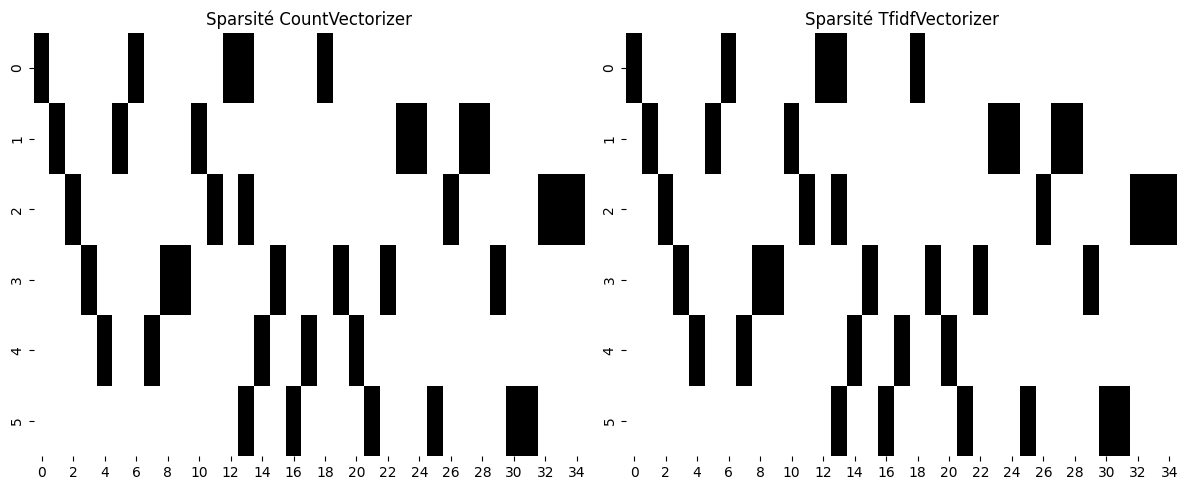

In [314]:
X_count_sparse = (X_count_vectorizer.toarray() != 0).astype(int)
X_tfidf_sparse = (X_tfidf_vectorizer.toarray() != 0).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax1 = axes[0]
sns.heatmap(X_count_sparse, ax=ax1, cmap="binary", cbar=False)
ax1.set_title("Sparsité CountVectorizer")

ax2 = axes[1]
sns.heatmap(X_tfidf_sparse, ax=ax2, cmap="binary", cbar=False)
ax2.set_title("Sparsité TfidfVectorizer")

plt.tight_layout()
plt.show()

Les deux matrices sont équivalentes selon les critères poids et spartissité.

### Tâche 5 : Influence de la normalisation

1. Entraînez deux `TfidfVectorizer` :
   - L1 norm (L1)
   - L2 norm (L2)
2. Comparez les scores TF-IDF obtenus
3. Visualisez les différences sur les 3 premiers documents
4. Expliquez : quelle norme utiliser et pourquoi?

**Attendus** : Comparaison L1/L2, recommandations justifiées

In [315]:
tfidf_vectorizer_l1 = TfidfVectorizer(
    lowercase=True,
    stop_words=stopwords.words("french"),
    min_df=1,
    max_features=100,
    norm="l1",
)

X_tfidf_vectorizer_l1 = tfidf_vectorizer_l1.fit_transform(critiques)

tfidf_vectorizer_l2 = TfidfVectorizer(
    lowercase=True,
    stop_words=stopwords.words("french"),
    min_df=1,
    max_features=100,
    norm="l2",
)

X_tfidf_vectorizer_l2 = tfidf_vectorizer_l2.fit_transform(critiques)

In [316]:
print("3 première lignes pour la norme l1 :\n", X_tfidf_vectorizer_l1[:3, :])
print("3 première lignes pour la norme l2 :\n", X_tfidf_vectorizer_l2[:3, :])

3 première lignes pour la norme l1 :
 <Compressed Sparse Row sparse matrix of dtype 'float64'
	with 19 stored elements and shape (3, 35)>
  Coords	Values
  (0, 13)	0.1475418429390486
  (0, 0)	0.21311453926523785
  (0, 12)	0.21311453926523785
  (0, 6)	0.21311453926523785
  (0, 18)	0.21311453926523785
  (1, 24)	0.14285714285714285
  (1, 10)	0.14285714285714285
  (1, 28)	0.14285714285714285
  (1, 23)	0.14285714285714285
  (1, 1)	0.14285714285714285
  (1, 27)	0.14285714285714285
  (1, 5)	0.14285714285714285
  (2, 13)	0.10344890954759477
  (2, 11)	0.14942518174206754
  (2, 32)	0.14942518174206754
  (2, 34)	0.14942518174206754
  (2, 2)	0.14942518174206754
  (2, 26)	0.14942518174206754
  (2, 33)	0.14942518174206754
3 première lignes pour la norme l2 :
 <Compressed Sparse Row sparse matrix of dtype 'float64'
	with 19 stored elements and shape (3, 35)>
  Coords	Values
  (0, 13)	0.32711255969869474
  (0, 0)	0.47249269128933835
  (0, 12)	0.47249269128933835
  (0, 6)	0.47249269128933835
  (0, 18)	

Les scores obtenus avec la norme $l_2$ sont supérieures aux scores obtenus avec la norme $l_1$.

* Le norme $l_1$ favorise la sparsité et permet de réduire la dimensionnalité.
* La norme $l_2$ pénalise les grandes valeurs et produit un modèle plus stable et robuste qu'avec la norme $l_1$.

### Tâche 6 : Application pratique

1. Créez une pipeline :
   - Nettoyage du texte (réutilisez l'exercice 1)
   - Vectorisation TF-IDF
2. Entraînez un classifieur simple (LogisticRegression)
3. Évaluez la performance (accuracy, precision, recall)

**Attendus** : Pipeline fonctionnel, prédiction sur nouveau texte

In [317]:
k = 4
critiques_train = critiques[:k]
critiques_test = critiques[k:]
labels_train = labels[:k]
labels_test = labels[k:]

nlp = spacy.load("fr_core_news_sm")


def preprocess(text):
    text = unidecode(text)
    text = re.sub(r"[^\w\s]", "", text)
    return text


def preprocess_with_lemmatization(text):
    text = unidecode(text)
    text = re.sub(r"[^\w\s]", "", text)
    doc = nlp(text)
    lemmatized_text = " ".join([token.lemma_ for token in doc if not token.is_stop])
    return lemmatized_text


pipeline = Pipeline(
    steps=[
        (
            "vect",
            TfidfVectorizer(
                preprocessor=preprocess,
                lowercase=True,
                stop_words=stopwords.words("french"),
                min_df=1,
                max_features=100,
                norm="l2",
            ),
        ),
        ("lr", LogisticRegression(random_state=42)),
    ]
)

lr_fitted = pipeline.fit(critiques_train, labels_train)

labels_pred_train = lr_fitted.predict(critiques_train)
labels_pred_test = lr_fitted.predict(critiques_test)

print("Accuracy train : ", accuracy_score(labels_train, labels_pred_train))
print("Accuracy test : ", accuracy_score(labels_test, labels_pred_test))
print("Precision : ", precision_score(labels_test, labels_pred_test))
print("Recall : ", recall_score(labels_test, labels_pred_test))
print("F1 score : ", f1_score(labels_test, labels_pred_test))

Accuracy train :  1.0
Accuracy test :  0.5
Precision :  0.5
Recall :  1.0
F1 score :  0.6666666666666666


## Bonus (Optionnel)

- Utilisez `max_features` pour comparer l'impact du vocabulaire réduit
- Testez différents `ngram_range` (unigrammes vs bigrammes)
- Implémentez votre propre TF-IDF depuis zéro
- Comparez les performances avec d'autres classifieurs (SVM, Random Forest)

In [318]:
maxs_features = [5, 10, 20, 50, 100]
results = {
    "max_features": [],
    "accuracy_score_train": [],
    "accuracy_score_test": [],
    "precision_score": [],
    "recall_score": [],
    "f1_score": [],
}


for max_features in maxs_features:
    pipeline = Pipeline(
        steps=[
            (
                "vect",
                TfidfVectorizer(
                    preprocessor=preprocess,
                    lowercase=True,
                    stop_words=stopwords.words("french"),
                    min_df=1,
                    max_features=max_features,
                    norm="l2",
                ),
            ),
            ("lr", LogisticRegression(random_state=42)),
        ]
    )

    lr_fitted = pipeline.fit(critiques_train, labels_train)

    labels_pred_train = lr_fitted.predict(critiques_train)
    labels_pred_test = lr_fitted.predict(critiques_test)

    results["max_features"].append(max_features)
    results["accuracy_score_train"].append(
        accuracy_score(labels_train, labels_pred_train)
    )
    results["accuracy_score_test"].append(accuracy_score(labels_test, labels_pred_test))
    results["precision_score"].append(precision_score(labels_test, labels_pred_test))
    results["recall_score"].append(recall_score(labels_test, labels_pred_test))
    results["f1_score"].append(f1_score(labels_test, labels_pred_test))

results_df = pd.DataFrame(results)
results_df.head()

,max_features,accuracy_score_train,accuracy_score_test,precision_score,recall_score,f1_score
0,5,1.0,0.0,0.0,0.0,0.000000
1,10,1.0,0.5,0.5,1.0,0.666667
2,20,1.0,0.5,0.5,1.0,0.666667
3,50,1.0,0.5,0.5,1.0,0.666667
4,100,1.0,0.5,0.5,1.0,0.666667


Si le nombre de features est trop petit, les scores du modèle descendent.

In [330]:
ngram_ranges = [(1, 1), (2, 2), (3, 3), (1, 2), (1, 3), (2, 3)]
results = {
    "ngram_range": [],
    "accuracy_score_train": [],
    "accuracy_score_test": [],
    "precision_score": [],
    "recall_score": [],
    "f1_score": [],
}

for ngram_range in ngram_ranges:
    pipeline = Pipeline(
        steps=[
            (
                "vect",
                TfidfVectorizer(
                    preprocessor=preprocess,
                    lowercase=True,
                    stop_words=stopwords.words("french"),
                    min_df=1,
                    max_features=100,
                    norm="l2",
                    ngram_range=ngram_range,
                ),
            ),
            ("lr", LogisticRegression(random_state=42)),
        ]
    )

    lr_fitted = pipeline.fit(critiques_train, labels_train)

    labels_pred_train = lr_fitted.predict(critiques_train)
    labels_pred_test = lr_fitted.predict(critiques_test)

    results["ngram_range"].append(ngram_range)
    results["accuracy_score_train"].append(
        accuracy_score(labels_train, labels_pred_train)
    )
    results["accuracy_score_test"].append(accuracy_score(labels_test, labels_pred_test))
    results["precision_score"].append(precision_score(labels_test, labels_pred_test))
    results["recall_score"].append(recall_score(labels_test, labels_pred_test))
    results["f1_score"].append(f1_score(labels_test, labels_pred_test))

results_df = pd.DataFrame(results)
results_df.head()

,ngram_range,accuracy_score_train,accuracy_score_test,precision_score,recall_score,f1_score
0,"(1, 1)",1.0,0.5,0.5,1.0,0.666667
1,"(2, 2)",1.0,0.5,0.0,0.0,0.000000
2,"(3, 3)",1.0,0.5,0.5,1.0,0.666667
3,"(1, 2)",1.0,0.5,0.5,1.0,0.666667
4,"(1, 3)",1.0,0.5,0.5,1.0,0.666667


La modification du paramètre ngram_range n'influe pas sur les scores.

In [321]:
classifiers = {
    "lr": LogisticRegression(random_state=42),
    "dt": DecisionTreeClassifier(random_state=42),
    "rf": RandomForestClassifier(random_state=42),
    "svc": SVC(random_state=42),
}
results = {
    "classifier": [],
    "accuracy_score_train": [],
    "accuracy_score_test": [],
    "precision_score": [],
    "recall_score": [],
    "f1_score": [],
}


for name, classifier in classifiers.items():
    pipeline = Pipeline(
        steps=[
            (
                "vect",
                TfidfVectorizer(
                    preprocessor=preprocess,
                    lowercase=True,
                    stop_words=stopwords.words("french"),
                    min_df=1,
                    max_features=max_features,
                    norm="l2",
                ),
            ),
            ("classifier", classifier),
        ]
    )

    lr_fitted = pipeline.fit(critiques_train, labels_train)

    labels_pred_train = lr_fitted.predict(critiques_train)
    labels_pred_test = lr_fitted.predict(critiques_test)

    results["classifier"].append(name)
    results["accuracy_score_train"].append(
        accuracy_score(labels_train, labels_pred_train)
    )
    results["accuracy_score_test"].append(accuracy_score(labels_test, labels_pred_test))
    results["precision_score"].append(precision_score(labels_test, labels_pred_test))
    results["recall_score"].append(recall_score(labels_test, labels_pred_test))
    results["f1_score"].append(f1_score(labels_test, labels_pred_test))

results_df = pd.DataFrame(results)
results_df.head()

,classifier,accuracy_score_train,accuracy_score_test,precision_score,recall_score,f1_score
0,lr,1.0,0.5,0.5,1.0,0.666667
1,dt,1.0,0.0,0.0,0.0,0.000000
2,rf,1.0,0.0,0.0,0.0,0.000000
3,svc,1.0,0.5,0.5,1.0,0.666667


Les modèles DecisionTree et RandomForest semblent avoir de moins bon résultats.

In [329]:
class TfidfCustom(TfidfVectorizer):
    def __init__(
        self,
        *,
        input="content",
        encoding="utf-8",
        decode_error="strict",
        strip_accents=None,
        lowercase=True,
        preprocessor=None,
        tokenizer=None,
        analyzer="word",
        stop_words=None,
        token_pattern=r"(?u)\b\w\w+\b",
        ngram_range=(1, 1),
        max_df=1,
        min_df=1,
        max_features=None,
        vocabulary=None,
        binary=False,
        dtype=np.float64,
        norm="l2",
        use_idf=True,
        smooth_idf=True,
        sublinear_tf=False,
    ):
        super().__init__(
            input=input,
            encoding=encoding,
            decode_error=decode_error,
            strip_accents=strip_accents,
            lowercase=lowercase,
            preprocessor=preprocessor,
            tokenizer=tokenizer,
            analyzer=analyzer,
            stop_words=stop_words,
            token_pattern=token_pattern,
            ngram_range=ngram_range,
            max_df=max_df,
            min_df=min_df,
            max_features=max_features,
            vocabulary=vocabulary,
            binary=binary,
            dtype=dtype,
            norm=norm,
            use_idf=use_idf,
            smooth_idf=smooth_idf,
            sublinear_tf=sublinear_tf,
        )
        self.preprocessor = self.custom_preprocessor
        self.lowercase = True
        self.stop_words = stopwords.words("french")
        self.min_df = 1
        self.max_features = 100
        self.norm = "l2"

    def custom_preprocessor(self, text):
        text = unidecode(text)
        text = re.sub(r"[^\w\s]", "", text)
        return text


tfidf_custom = TfidfCustom()

print(tfidf_custom.fit_transform(critiques))

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 38 stored elements and shape (6, 38)>
  Coords	Values
  (0, 1)	0.408248290463863
  (0, 11)	0.408248290463863
  (0, 22)	0.408248290463863
  (0, 4)	0.408248290463863
  (0, 16)	0.408248290463863
  (0, 26)	0.408248290463863
  (1, 9)	0.3779644730092272
  (1, 20)	0.3779644730092272
  (1, 33)	0.3779644730092272
  (1, 28)	0.3779644730092272
  (1, 12)	0.3779644730092272
  (1, 32)	0.3779644730092272
  (1, 15)	0.3779644730092272
  (2, 21)	0.408248290463863
  (2, 10)	0.408248290463863
  (2, 19)	0.408248290463863
  (2, 13)	0.408248290463863
  (2, 30)	0.408248290463863
  (2, 37)	0.408248290463863
  (3, 2)	0.35355339059327373
  (3, 5)	0.35355339059327373
  (3, 18)	0.35355339059327373
  (3, 34)	0.35355339059327373
  (3, 14)	0.35355339059327373
  (3, 25)	0.35355339059327373
  (3, 27)	0.35355339059327373
  (3, 29)	0.35355339059327373
  (4, 6)	0.4472135954999579
  (4, 24)	0.4472135954999579
  (4, 0)	0.4472135954999579
  (4, 17)	0.4472135954999